In [ ]:
# STEP 1 — Import libraries
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

In [ ]:
# STEP 2 — Load dataset
DATA_PATHS = [
    "Credit Risk Benchmark Dataset.csv",
    "/mnt/data/Credit Risk Benchmark Dataset.csv"
]

DATA_PATH = next((p for p in DATA_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Credit Risk Benchmark Dataset.csv was not found.")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


In [ ]:
# STEP 3 — Basic data audit
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

assert "dlq_2yrs" in df.columns, "Target column 'dlq_2yrs' is missing."
assert set(df["dlq_2yrs"].dropna().unique()).issubset({0, 1}), "Target must contain only 0 and 1."

print("\nTarget values:", sorted(df["dlq_2yrs"].unique()))

In [ ]:
# STEP 4 — Clean exact duplicates
rows_before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df_clean)

print("Rows before duplicate removal:", rows_before)
print("Duplicate rows removed:", rows_before - rows_after)
print("Rows after cleaning:", rows_after)

target_counts = df_clean["dlq_2yrs"].value_counts().sort_index()
print("\nTarget counts:")
display(target_counts.to_frame("count"))

target_pct = (target_counts / len(df_clean) * 100).round(2)
print("\nTarget percentage:")
display(target_pct.to_frame("percentage"))

In [ ]:
# STEP 5 — Target distribution
labels = ["0 = No serious delinquency", "1 = Serious delinquency"]
counts = [target_counts.get(0, 0), target_counts.get(1, 0)]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts)
plt.ylabel("Number of borrowers")
plt.title("Target Distribution: Serious Delinquency Within 2 Years")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Class 0: {counts[0]:,} ({counts[0]/len(df_clean)*100:.2f}%)")
print(f"Class 1: {counts[1]:,} ({counts[1]/len(df_clean)*100:.2f}%)")

In [ ]:
# STEP 6 — Descriptive statistics
display(df_clean.describe().T)

In [ ]:
# STEP 7 — Missing-value percentage
missing_pct = df_clean.isna().mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_pct.index, missing_pct.values)
plt.ylabel("Missing values (%)")
plt.title("Missing Values by Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(missing_pct.to_frame("missing_percentage"))

In [ ]:
# STEP 8 — Separate feature columns
TARGET = "dlq_2yrs"
feature_cols = [c for c in df_clean.columns if c != TARGET]

print("Number of features:", len(feature_cols))
print("Features:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

In [ ]:
# STEP 9 — Histograms for all numerical features
for col in feature_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df_clean[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 10 — Boxplots for all features
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_clean[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 11 — Feature vs target boxplots
for col in feature_cols:
    group0 = df_clean.loc[df_clean[TARGET] == 0, col].dropna()
    group1 = df_clean.loc[df_clean[TARGET] == 1, col].dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot([group0, group1], labels=["0 = No delinquency", "1 = Delinquency"])
    plt.ylabel(col)
    plt.title(f"{col} vs 2-Year Serious Delinquency")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 12 — Group statistics by target
group_stats = df_clean.groupby(TARGET)[feature_cols].agg(["mean", "median", "std"])
display(group_stats.T)

mean_by_target = df_clean.groupby(TARGET)[feature_cols].mean().T
median_by_target = df_clean.groupby(TARGET)[feature_cols].median().T

for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar(["No delinquency", "Delinquency"],
                [mean_by_target.loc[col, 0], mean_by_target.loc[col, 1]])
    axes[0].set_title(f"Mean: {col}")
    axes[0].set_ylabel(col)

    axes[1].bar(["No delinquency", "Delinquency"],
                [median_by_target.loc[col, 0], median_by_target.loc[col, 1]])
    axes[1].set_title(f"Median: {col}")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 13 — Quantile-binned delinquency rate for every feature
for col in feature_cols:
    temp = df_clean[[col, TARGET]].dropna().copy()

    try:
        temp["bin"] = pd.qcut(temp[col], q=8, duplicates="drop")
        rate = temp.groupby("bin", observed=True)[TARGET].mean() * 100

        plt.figure(figsize=(9, 5))
        plt.plot(range(len(rate)), rate.values, marker="o")
        plt.xticks(range(len(rate)), [str(x) for x in rate.index], rotation=45, ha="right")
        plt.ylabel("Delinquency rate (%)")
        plt.xlabel(f"{col} quantile bin")
        plt.title(f"Observed Delinquency Rate Across {col}")
        plt.tight_layout()
        plt.show()
    except ValueError:
        print(f"Could not create quantile bins for {col}.")

In [ ]:
# STEP 14 — Correlation matrix
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation with target:")
display(corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).to_frame("correlation"))

In [ ]:
# STEP 15 — Feature vs target scatter/strip-style plots
for col in feature_cols:
    plt.figure(figsize=(8, 5))

    for target_value in [0, 1]:
        vals = df_clean.loc[df_clean[TARGET] == target_value, col].to_numpy()
        x = np.full(len(vals), target_value, dtype=float)
        jitter = np.random.default_rng(RANDOM_STATE).normal(0, 0.04, len(vals))
        plt.scatter(x + jitter, vals, alpha=0.18, s=12, label=f"Target {target_value}")

    plt.xticks([0, 1], ["No delinquency", "Delinquency"])
    plt.ylabel(col)
    plt.title(f"{col} vs {TARGET}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 16 — Pairwise feature relationship matrix on a sample
sample_n = min(1500, len(df_clean))
plot_sample = df_clean[feature_cols + [TARGET]].sample(
    n=sample_n, random_state=RANDOM_STATE
)

pd.plotting.scatter_matrix(
    plot_sample[feature_cols],
    figsize=(16, 16),
    diagonal="hist",
    alpha=0.25
)
plt.suptitle("Pairwise Feature Relationships (Sample)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 17 — Separate features and target
X = df_clean[feature_cols].copy()
y = df_clean[TARGET].astype(int).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

In [ ]:
# STEP 18 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).to_frame("percentage"))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).to_frame("percentage"))

In [ ]:
# STEP 19 — Leakage-safe preprocessing
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

print("Preprocessing pipeline created.")
print(preprocessor)

In [ ]:
# STEP 20 — Define models
models = {
    "Linear Regression": LinearRegression(),

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=6,
        min_samples_leaf=10
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance"
    )
}

for name, model in models.items():
    print(f"{name}: {model}")

In [21]:
# STEP 21 — Train and evaluate all models
results = []
trained_models = {}
predictions = {}
scores = {}

for name, estimator in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)

    # Predictions
    if name == "Linear Regression":
        score = pipe.predict(X_test)
        pred = (score >= 0.5).astype(int)
    else:
        pred = pipe.predict(X_test)
        score = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, score),
        "PR_AUC": average_precision_score(y_test, score)
    })

    trained_models[name] = pipe
    predictions[name] = pred
    scores[name] = score

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "PR_AUC": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.7759,0.7787,0.7708,0.7747,0.8533,0.8460
1,Decision Tree,0.7595,0.7456,0.7876,0.7660,0.8399,0.8226
2,KNN,0.7610,0.7861,0.7169,0.7499,0.8339,0.8285
3,Logistic Regression,0.7269,0.7889,0.6194,0.6939,0.7952,0.8125
4,SVM,0.5052,0.5026,0.9928,0.6673,0.5000,0.4999
5,Linear Regression,0.6288,0.6334,0.6110,0.6220,0.6859,0.7136


In [22]:
# STEP 22 — Detailed classification reports
for name in models:
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        y_test,
        predictions[name],
        target_names=["No delinquency (0)", "Delinquency (1)"],
        digits=4,
        zero_division=0
    ))


Linear Regression
                    precision    recall  f1-score   support

No delinquency (0)     0.6245    0.6465    0.6353      1672
   Delinquency (1)     0.6334    0.6110    0.6220      1671

          accuracy                         0.6288      3343
         macro avg     0.6289    0.6288    0.6287      3343
      weighted avg     0.6289    0.6288    0.6287      3343


Logistic Regression
                    precision    recall  f1-score   support

No delinquency (0)     0.6869    0.8343    0.7534      1672
   Delinquency (1)     0.7889    0.6194    0.6939      1671

          accuracy                         0.7269      3343
         macro avg     0.7379    0.7269    0.7237      3343
      weighted avg     0.7378    0.7269    0.7237      3343


Decision Tree
                    precision    recall  f1-score   support

No delinquency (0)     0.7750    0.7315    0.7526      1672
   Delinquency (1)     0.7456    0.7876    0.7660      1671

          accuracy                   

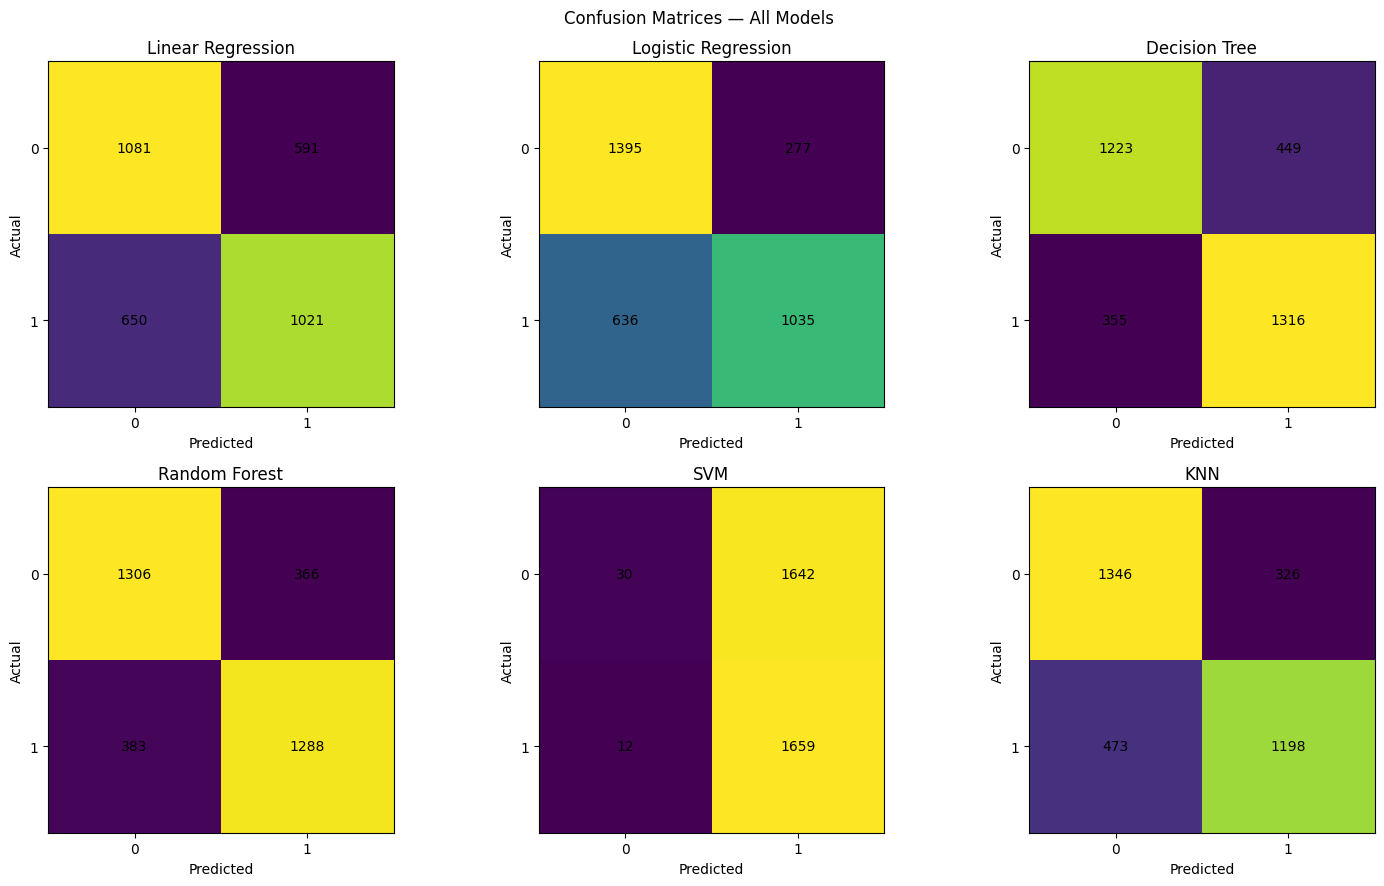

In [23]:
# STEP 23 — Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])

    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["0", "1"])
    ax.set_yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.suptitle("Confusion Matrices — All Models")
plt.tight_layout()
plt.show()

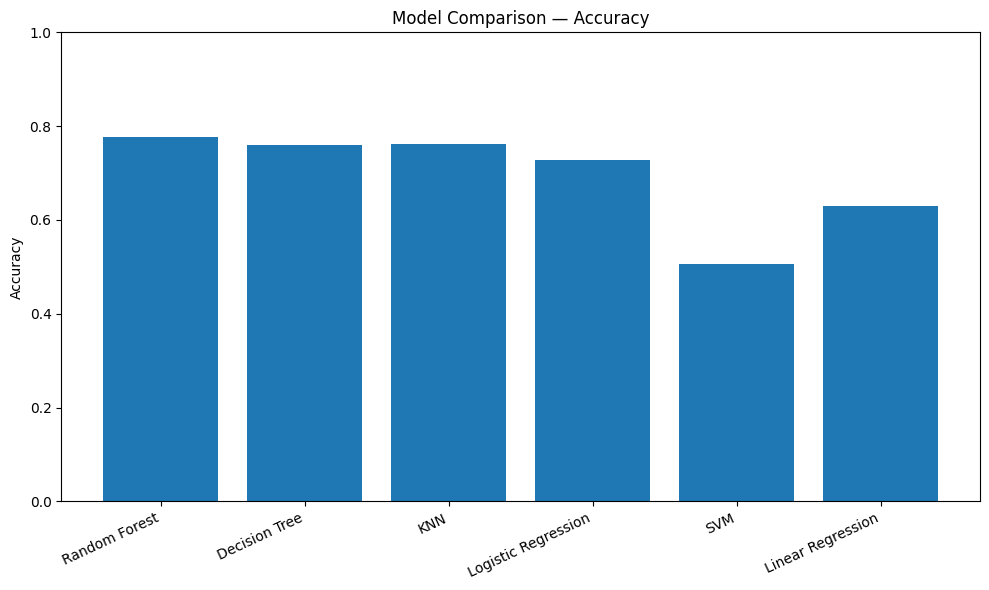

In [24]:
# STEP 24 — Accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison — Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

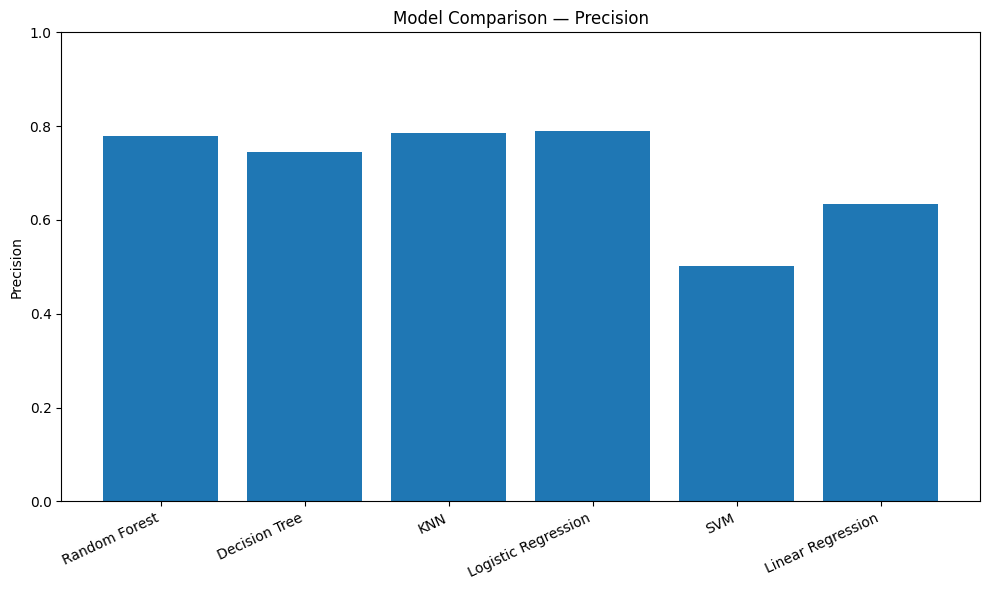

In [25]:
# STEP 25 — Precision comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Precision"])
plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Model Comparison — Precision")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

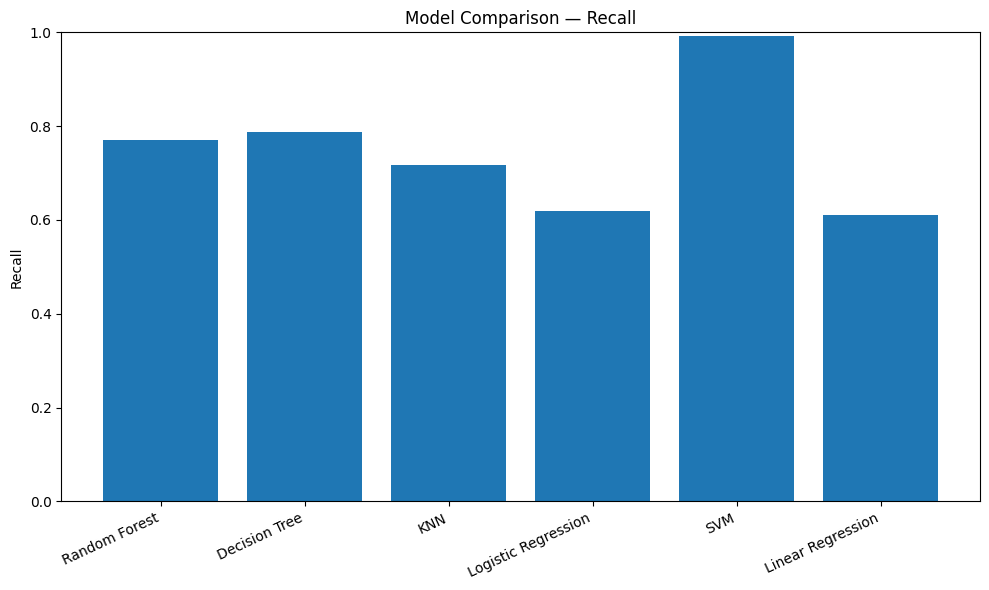

In [26]:
# STEP 26 — Recall comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Recall"])
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Model Comparison — Recall")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

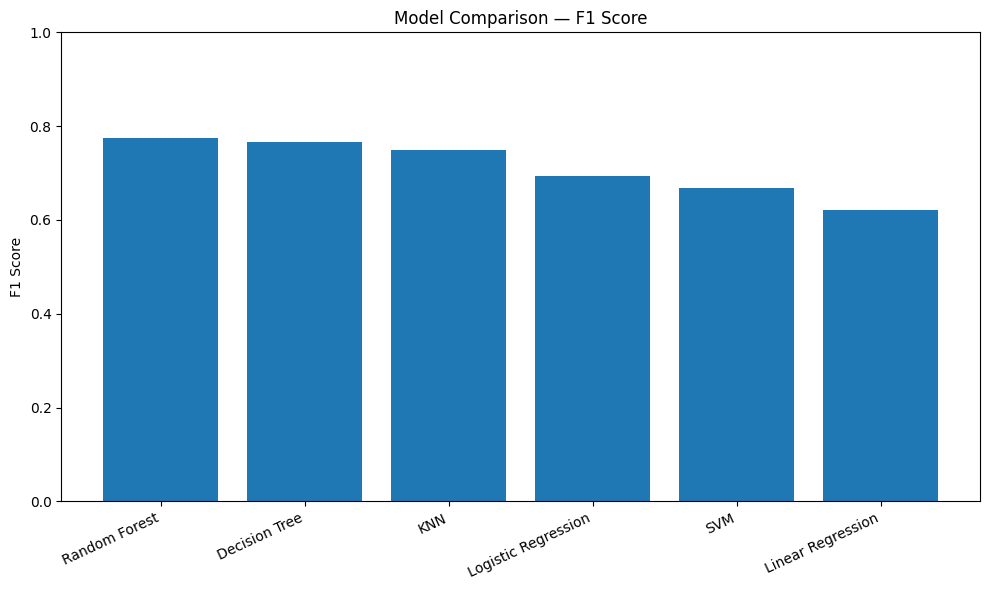

In [27]:
# STEP 27 — F1 comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["F1"])
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Model Comparison — F1 Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

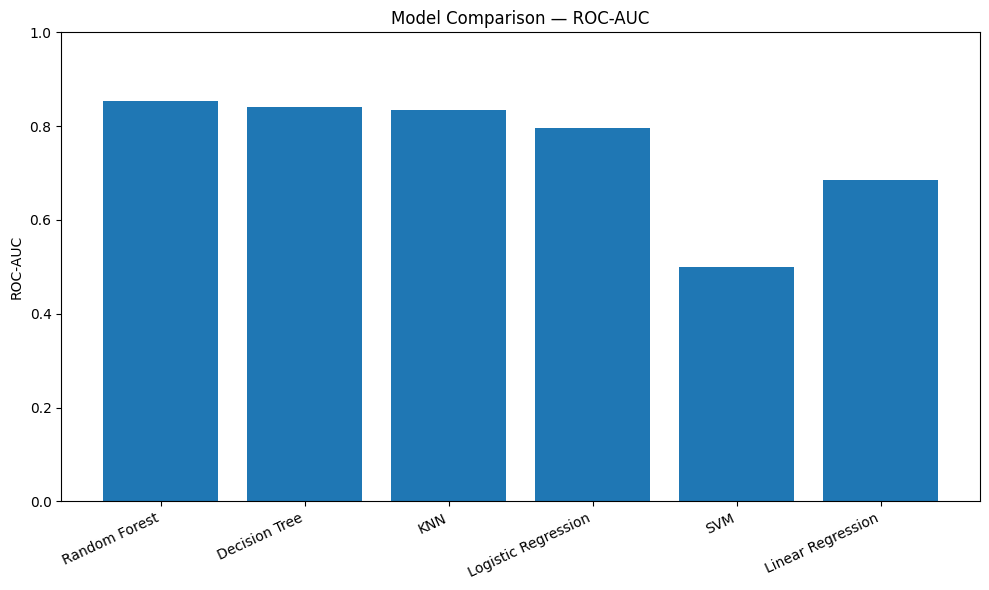

In [28]:
# STEP 28 — ROC-AUC comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model Comparison — ROC-AUC")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

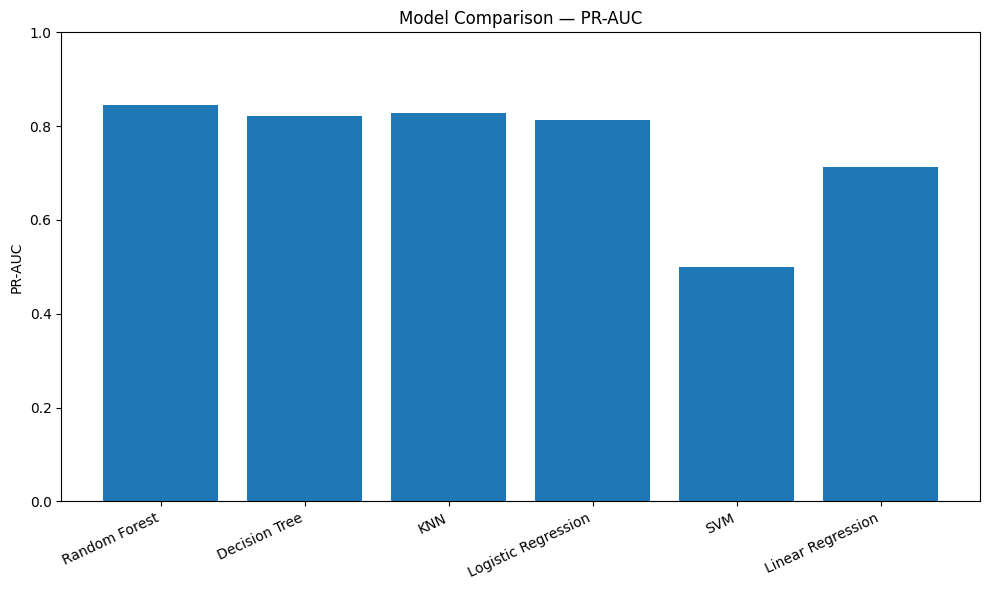

In [29]:
# STEP 29 — PR-AUC comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["PR_AUC"])
plt.ylim(0, 1)
plt.ylabel("PR-AUC")
plt.title("Model Comparison — PR-AUC")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

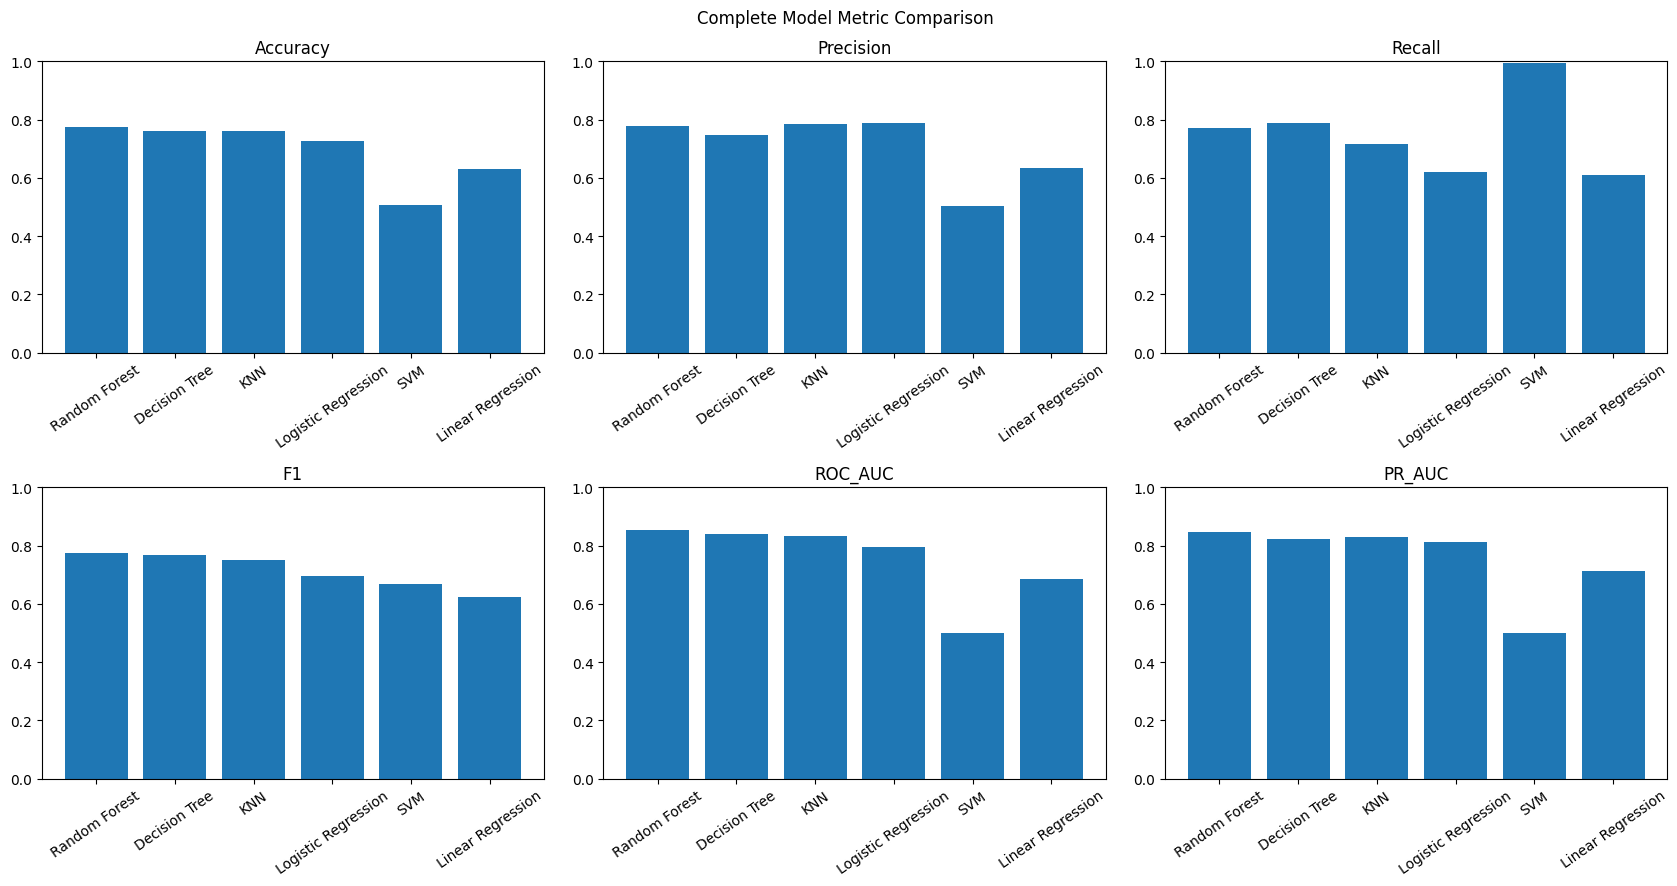

In [30]:
# STEP 30 — All classification metrics in one figure
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

for ax, metric in zip(axes, metric_cols):
    ax.bar(results_df["Model"], results_df[metric])
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=35)

plt.suptitle("Complete Model Metric Comparison")
plt.tight_layout()
plt.show()

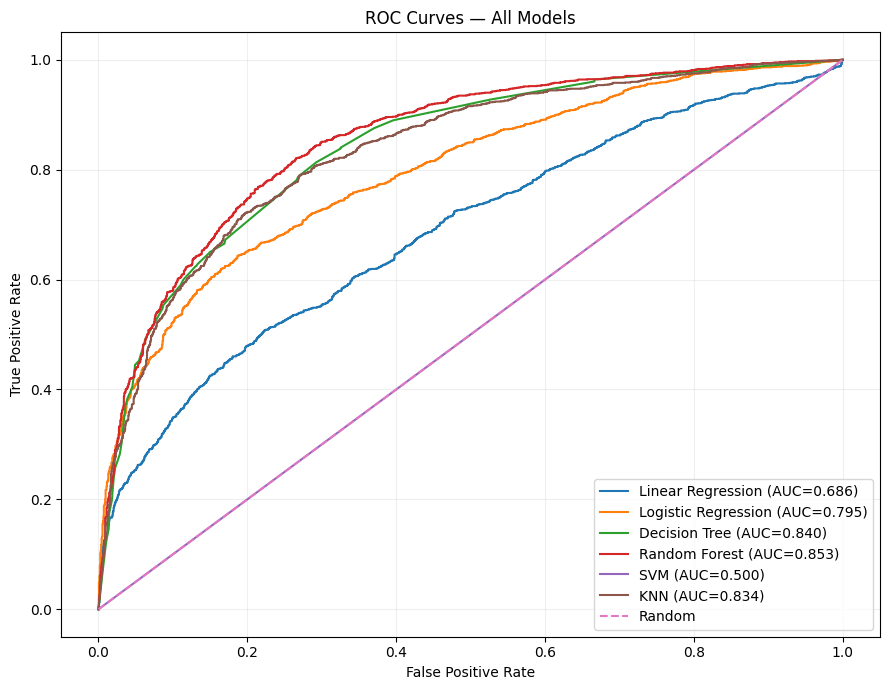

In [31]:
# STEP 31 — ROC curves
plt.figure(figsize=(9, 7))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc = roc_auc_score(y_test, scores[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

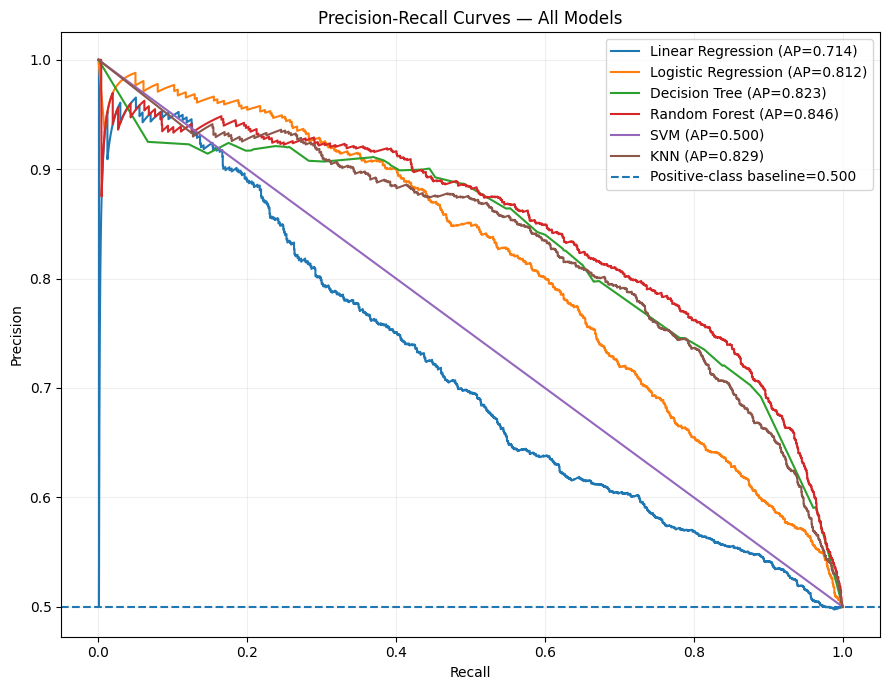

In [32]:
# STEP 32 — Precision-Recall curves
plt.figure(figsize=(9, 7))

baseline = y_test.mean()
for name in models:
    precision, recall, _ = precision_recall_curve(y_test, scores[name])
    ap = average_precision_score(y_test, scores[name])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.axhline(baseline, linestyle="--", label=f"Positive-class baseline={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

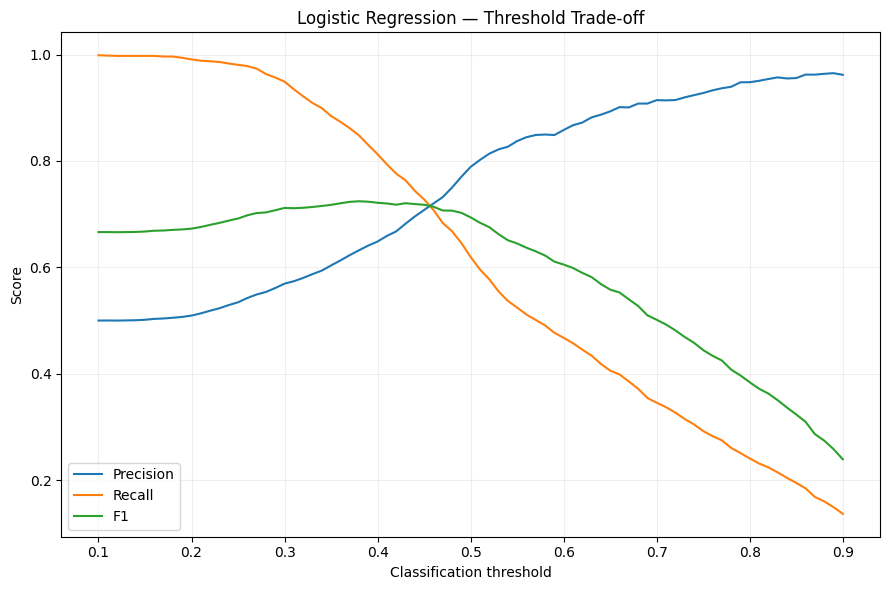

Threshold with maximum test-set F1 (for analysis only):


,value
Threshold,0.3800
Precision,0.6320
Recall,0.8480
F1,0.7243


In [33]:
# STEP 33 — Logistic Regression threshold analysis
log_scores = scores["Logistic Regression"]

thresholds = np.linspace(0.10, 0.90, 81)
threshold_rows = []

for threshold in thresholds:
    pred_t = (log_scores >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "F1": f1_score(y_test, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

plt.figure(figsize=(9, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Logistic Regression — Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print("Threshold with maximum test-set F1 (for analysis only):")
display(best_threshold_row.to_frame("value"))

In [6]:
# STEP 34 — 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    scoring = "roc_auc"
    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV ROC-AUC Mean": cv_scores.mean(),
        "CV ROC-AUC Std": cv_scores.std(),
        "Fold 1": cv_scores[0],
        "Fold 2": cv_scores[1],
        "Fold 3": cv_scores[2],
        "Fold 4": cv_scores[3],
        "Fold 5": cv_scores[4]
    })

cv_df = pd.DataFrame(cv_rows).sort_values(
    "CV ROC-AUC Mean", ascending=False
).reset_index(drop=True)

display(cv_df.style.format({
    c: "{:.4f}" for c in cv_df.columns if c != "Model"
}))

NameError: name 'StratifiedKFold' is not defined

In [7]:
# STEP 35 — CV ROC-AUC with standard deviation
plt.figure(figsize=(10, 6))

x = np.arange(len(cv_df))
plt.bar(
    x,
    cv_df["CV ROC-AUC Mean"],
    yerr=cv_df["CV ROC-AUC Std"],
    capsize=5
)

plt.xticks(x, cv_df["Model"], rotation=25, ha="right")
plt.ylabel("Mean CV ROC-AUC")
plt.title("5-Fold Stratified Cross-Validation — ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# STEP 36 — Random Forest feature importance
rf_pipe = trained_models["Random Forest"]

rf_model = rf_pipe.named_steps["model"]
rf_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 37 — Logistic Regression coefficients
log_pipe = trained_models["Logistic Regression"]
log_model = log_pipe.named_steps["model"]

log_coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_model.coef_[0]
})

log_coefficients["Abs_Coefficient"] = log_coefficients["Coefficient"].abs()
log_coefficients = log_coefficients.sort_values(
    "Abs_Coefficient", ascending=False
)

display(log_coefficients)

plt.figure(figsize=(10, 6))
plt.barh(
    log_coefficients["Feature"],
    log_coefficients["Coefficient"]
)
plt.axvline(0, linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 38 — Linear Regression residuals
linear_pipe = trained_models["Linear Regression"]

linear_pred = linear_pipe.predict(X_test)
linear_residuals = y_test.to_numpy() - linear_pred

plt.figure(figsize=(9, 5))
plt.scatter(linear_pred, linear_residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Linear Regression — Residual Plot")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 39 — Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.35)

minimum = min(y_test.min(), linear_pred.min())
maximum = max(y_test.max(), linear_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual target")
plt.ylabel("Predicted value")
plt.title("Linear Regression — Actual vs Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 40 — Logistic Regression score distributions
plt.figure(figsize=(9, 6))

for outcome_value, label in [(0, "Actual 0"), (1, "Actual 1")]:
    vals = log_scores[y_test.to_numpy() == outcome_value]
    plt.hist(vals, bins=30, alpha=0.55, label=label)

plt.xlabel("Predicted probability of delinquency")
plt.ylabel("Frequency")
plt.title("Logistic Regression — Prediction Score Distributions")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# STEP 41 — Learning curves
learning_curve_models = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

for name in learning_curve_models:
    pipe = trained_models[name]

    train_sizes, train_scores, valid_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
    plt.plot(train_sizes, valid_mean, marker="o", label="Validation ROC-AUC")
    plt.xlabel("Training examples")
    plt.ylabel("ROC-AUC")
    plt.title(f"Learning Curve — {name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 42 — Final ranking
ranking_df = results_df.sort_values(
    ["F1", "PR_AUC", "Recall", "ROC_AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

ranking_df.insert(0, "Rank", np.arange(1, len(ranking_df) + 1))

display(ranking_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "PR_AUC": "{:.4f}"
}))

best_model_name = ranking_df.iloc[0]["Model"]
print(f"\n Best overall model by the selected ranking rule: {best_model_name}")

In [ ]:
# STEP 43 — Automated final interpretation
best_row = ranking_df.iloc[0]

print("FINAL MODEL SUMMARY")
print("=" * 70)
print(f"Recommended benchmark winner : {best_row['Model']}")
print(f"F1 Score                    : {best_row['F1']:.4f}")
print(f"Recall                      : {best_row['Recall']:.4f}")
print(f"Precision                   : {best_row['Precision']:.4f}")
print(f"ROC-AUC                     : {best_row['ROC_AUC']:.4f}")
print(f"PR-AUC                      : {best_row['PR_AUC']:.4f}")
print(f"Accuracy                    : {best_row['Accuracy']:.4f}")

cv_best = cv_df.iloc[0]
print("\nMost stable/highest mean CV ROC-AUC model:")
print(f"{cv_best['Model']} — {cv_best['CV ROC-AUC Mean']:.4f} ± {cv_best['CV ROC-AUC Std']:.4f}")

In [ ]:
# STEP 44 — Save outputs
OUTPUT_DIR = "credit_risk_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_clean.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_cleaned.csv"),
    index=False
)

results_df.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_model_comparison.csv"),
    index=False
)

cv_df.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_cross_validation.csv"),
    index=False
)

importance_df.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_random_forest_feature_importance.csv"),
    index=False
)

log_coefficients.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_logistic_coefficients.csv"),
    index=False
)

threshold_df.to_csv(
    os.path.join(OUTPUT_DIR, "credit_risk_logistic_threshold_analysis.csv"),
    index=False
)

print("All result files saved inside:", OUTPUT_DIR)